In [4]:
!pip install lmdb

Using device: cuda
Data dir: /home/jovyan/work/ocr/data
The total number of base characters is 36
Train path: /home/jovyan/work/ocr/data/MJ/MJ_train
[Sample 1] raw=(72,31), resized=(74, 32), label=Lube


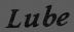

[Sample 2] raw=(82,31), resized=(84, 32), label=Spencerian


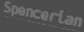

In [1]:
# =========================
# Attention OCR (CRNN-1D encoder + Bahdanau Attention decoder)
# - Height -> 1, sequence along width only (T ≈ W/4)
# - Enc mask to ignore padded width steps
# - AMP on, AdamW, channels_last, DataLoader tuned
# - FIX: masked_fill uses dtype-specific min to avoid fp16 overflow
# =========================
import os, re, six, lmdb, time, math
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display
from tqdm.auto import tqdm

# -------------------------
# Device & Backend Tweaks
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

# -------------------------
# Paths & Charset
# -------------------------
data_dir = os.path.join(os.getenv("HOME"), "work/ocr/data")
os.chdir(data_dir)
print("Data dir:", data_dir)

NUMBERS = "0123456789"
ENG_CHAR_UPPER = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
BASE_CHARSET = ENG_CHAR_UPPER + NUMBERS   # 36개
print(f"The total number of base characters is {len(BASE_CHARSET)}")

TRAIN_DATA_PATH = os.path.join(data_dir, 'MJ/MJ_train')
VALID_DATA_PATH = os.path.join(data_dir, 'MJ/MJ_valid')
TEST_DATA_PATH  = os.path.join(data_dir, 'MJ/MJ_test')
print("Train path:", TRAIN_DATA_PATH)

# -------------------------
# Quick LMDB glance (optional)
# -------------------------
_env = lmdb.open(TRAIN_DATA_PATH, max_readers=32, readonly=True, lock=False, readahead=False, meminit=False)
with _env.begin(write=False) as txn:
    for index in range(1, 3):
        label_key = f"label-{index:09d}".encode()
        label = txn.get(label_key).decode('utf-8')
        img_key = f"image-{index:09d}".encode()
        imgbuf = txn.get(img_key)
        buf = six.BytesIO(); buf.write(imgbuf); buf.seek(0)
        try:
            img = Image.open(buf).convert('RGB')
        except IOError:
            img = Image.new('RGB', (100, 32)); label = '-'
        w, h = img.size
        target_w = min(int(w*32/h), 100)
        img_np = np.array(img.resize((target_w, 32))).transpose(1,0,2)
        print(f"[Sample {index}] raw=({w},{h}), resized={(target_w,32)}, label={label}")
        display(Image.fromarray(img_np.transpose(1,0,2).astype(np.uint8)))

In [2]:
# -------------------------
# Vocabulary (PAD/SOS/EOS)
# -------------------------
class Vocab:
    PAD = '<pad>'
    SOS = '<s>'
    EOS = '</s>'

    def __init__(self, base_charset: str):
        self.tokens = [self.PAD, self.SOS, self.EOS] + list(base_charset)
        self.stoi = {s:i for i, s in enumerate(self.tokens)}
        self.itos = {i:s for i, s in enumerate(self.tokens)}
        self.pad_idx = self.stoi[self.PAD]
        self.sos_idx = self.stoi[self.SOS]
        self.eos_idx = self.stoi[self.EOS]

    def encode_str(self, s: str):
        s = s.upper()
        return [self.stoi[ch] for ch in s if ch in self.stoi]

    def decode_ids(self, ids):
        out = []
        for i in ids:
            tok = self.itos.get(int(i), '')
            if tok == self.EOS: break
            if tok in (self.PAD, self.SOS) or tok == '': continue
            out.append(tok)
        return ''.join(out)

vocab = Vocab(BASE_CHARSET)
VOCAB_SIZE = len(vocab.tokens)
print("VOCAB_SIZE:", VOCAB_SIZE, "PAD:", vocab.pad_idx, "SOS:", vocab.sos_idx, "EOS:", vocab.eos_idx)

VOCAB_SIZE: 39 PAD: 0 SOS: 1 EOS: 2


In [3]:
# -------------------------
# Dataset (LMDB) with width-steps
# -------------------------
def width_to_steps(target_w):
    # pools: (2,2)->(2,2)->(2,1)->(2,1)->(2,1) ⇒ width_out ≈ target_w/4
    return max(1, target_w // 4)

class MJDataset(Dataset):
    def __init__(self, dataset_path, vocab: Vocab, img_size=(100, 32), max_text_len=22, character=""):
        super().__init__()
        self.vocab = vocab
        self.img_size = img_size  # (W, H)
        self.max_text_len = max_text_len
        self.character = character if character else BASE_CHARSET

        self.env = lmdb.open(dataset_path, max_readers=32, readonly=True, lock=False, readahead=False, meminit=False)
        with self.env.begin(write=False) as txn:
            self.num_samples = int(txn.get("num-samples".encode()))
            self.index_list = [i + 1 for i in range(self.num_samples)]

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        index = self.index_list[idx]
        with self.env.begin(write=False) as txn:
            label_key = f"label-{index:09d}".encode()
            label = txn.get(label_key).decode("utf-8")
            img_key = f"image-{index:09d}".encode()
            imgbuf = txn.get(img_key)
            buf = six.BytesIO(); buf.write(imgbuf); buf.seek(0)
            try:
                img_pil = Image.open(buf).convert("RGB")
            except IOError:
                img_pil = Image.new("RGB", self.img_size); label = "-"

        orig_w, orig_h = img_pil.size
        target_w = min(int(orig_w * self.img_size[1] / orig_h), self.img_size[0])
        img_pil = img_pil.resize((target_w, self.img_size[1]))

        img = np.array(img_pil, dtype=np.float32) / 255.0
        img = img.transpose(2, 0, 1)  # CHW
        padded = np.zeros((3, self.img_size[1], self.img_size[0]), dtype=np.float32)
        c, h, w = img.shape
        padded[:, :h, :w] = img
        img_t = torch.from_numpy(padded)  # float32 CHW

        # targets
        label = label.upper()
        label = re.sub(f"[^{self.character}]", "", label)
        label = label[: self.max_text_len]
        label_ids = self.vocab.encode_str(label)

        # valid encoder steps along width after CNN
        t_steps = width_to_steps(target_w)  # <= 25 (if W=100)
        return img_t, label_ids, len(label_ids), label, t_steps

def collate_fn_attn(batch):
    imgs, label_ids_list, label_lens, raw_labels, t_steps = zip(*batch)
    imgs = torch.stack(imgs, dim=0)  # (B,3,H,W)

    # Build decoder input/output sequences
    max_len = max(label_lens)
    B = len(batch)
    inp = torch.full((B, max_len+1), fill_value=vocab.pad_idx, dtype=torch.long)
    tgt = torch.full((B, max_len+1), fill_value=vocab.pad_idx, dtype=torch.long)
    for i, ids in enumerate(label_ids_list):
        L = len(ids)
        inp[i, 0] = vocab.sos_idx
        if L > 0: inp[i, 1:1+L] = torch.tensor(ids, dtype=torch.long)
        tgt[i, :L] = torch.tensor(ids, dtype=torch.long)
        tgt[i, L] = vocab.eos_idx

    # encoder mask for width steps
    max_T = max(t_steps)
    enc_mask = torch.zeros((B, max_T), dtype=torch.bool)
    for i, tlen in enumerate(t_steps):
        enc_mask[i, :tlen] = True

    tgt_lengths = torch.tensor([len(ids)+1 for ids in label_ids_list], dtype=torch.long)
    return imgs, inp, tgt, tgt_lengths, raw_labels, enc_mask

In [4]:
# -------------------------
# Encoder (CRNN-1D: height->1, sequence along width)
# -------------------------
class CRNN1DEncoder(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        # Keep width; squash height to 1
        self.conv1 = nn.Conv2d(3,   64, 3, padding=1)
        self.pool1 = nn.MaxPool2d((2,2))   # H/2, W/2
        self.conv2 = nn.Conv2d(64,  128, 3, padding=1)
        self.pool2 = nn.MaxPool2d((2,2))   # H/4, W/4
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d((2,1))   # H/8,  W/4
        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5   = nn.BatchNorm2d(512)
        self.conv6 = nn.Conv2d(512, 512, 3, padding=1)
        self.bn6   = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d((2,1))   # H/16, W/4
        self.conv7 = nn.Conv2d(512, 512, 3, padding=1)
        self.pool5 = nn.MaxPool2d((2,1))   # H/32 -> 1,  W/4

        # BiLSTM over width steps
        self.rnn1 = nn.LSTM(512, 256, batch_first=True, bidirectional=True)
        self.rnn2 = nn.LSTM(512, 256, batch_first=True, bidirectional=True)
        self.out_dim = out_dim

    def forward(self, x):
        # x: (B,3,32,100)
        x = F.relu(self.conv1(x)); x = self.pool1(x)           # (B,64,16,50)
        x = F.relu(self.conv2(x)); x = self.pool2(x)           # (B,128,8,25)
        x = F.relu(self.conv3(x)); x = F.relu(self.conv4(x)); x = self.pool3(x)  # (B,256,4,25)
        x = F.relu(self.conv5(x)); x = self.bn5(x)
        x = F.relu(self.conv6(x)); x = self.bn6(x); x = self.pool4(x)            # (B,512,2,25)
        x = F.relu(self.conv7(x)); x = self.pool5(x)                              # (B,512,1,25)

        # collapse height -> sequence along width
        x = x.squeeze(2)                  # (B,512,25)
        x = x.permute(0, 2, 1)            # (B,25,512)

        x, _ = self.rnn1(x)               # (B,25,512)
        x, _ = self.rnn2(x)               # (B,25,512)
        return x  # (B,T≈W/4,512)

In [5]:
# -------------------------
# Bahdanau Attention (FIXED mask value)
# -------------------------
class AdditiveAttention(nn.Module):
    def __init__(self, enc_dim=512, dec_dim=256, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v   = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, enc_out, dec_state, precomp_enc=None, mask=None):
        """
        enc_out: (B,T,E), dec_state: (B,D), mask: (B,T) bool (True=valid)
        """
        if precomp_enc is None:
            precomp_enc = self.W_h(enc_out)  # (B,T,A)
        s = self.W_s(dec_state).unsqueeze(1) # (B,1,A)
        e = self.v(torch.tanh(precomp_enc + s)).squeeze(-1)  # (B,T)

        if mask is not None:
            # Use dtype-specific minimum to avoid fp16 overflow
            neg_inf = torch.finfo(e.dtype).min
            e = e.masked_fill(~mask, neg_inf)

        a = F.softmax(e, dim=1)              # (B,T)
        ctx = torch.bmm(a.unsqueeze(1), enc_out).squeeze(1)  # (B,E)
        return ctx, a

In [6]:
# -------------------------
# Decoder with Attention
# -------------------------
class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, enc_dim=512, dec_dim=256, emb_dim=256, attn_dim=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=vocab.pad_idx)
        self.attn = AdditiveAttention(enc_dim, dec_dim, attn_dim)
        self.rnn = nn.LSTMCell(emb_dim + enc_dim, dec_dim)
        self.fc  = nn.Linear(dec_dim + enc_dim, vocab_size)

    def forward(self, enc_out, tgt_inp, enc_mask=None):
        B, T, E = enc_out.size()
        L = tgt_inp.size(1)
        pre = self.attn.W_h(enc_out)

        h = torch.zeros(B, self.rnn.hidden_size, device=enc_out.device)
        c = torch.zeros_like(h)
        ctx = torch.zeros(B, E, device=enc_out.device)

        logits = []
        for t in range(L):
            emb = self.emb(tgt_inp[:, t])
            h, c = self.rnn(torch.cat([emb, ctx], dim=-1), (h, c))
            ctx, _ = self.attn(enc_out, h, precomp_enc=pre, mask=enc_mask)
            out = self.fc(torch.cat([h, ctx], dim=-1))
            logits.append(out.unsqueeze(1))
        return torch.cat(logits, dim=1)  # (B,L,V)

    @torch.no_grad()
    def greedy_decode(self, enc_out, max_len=25, sos_idx=None, eos_idx=None, enc_mask=None):
        B, T, E = enc_out.size()
        pre = self.attn.W_h(enc_out)
        if sos_idx is None: sos_idx = vocab.sos_idx
        if eos_idx is None: eos_idx = vocab.eos_idx

        h = torch.zeros(B, self.rnn.hidden_size, device=enc_out.device)
        c = torch.zeros_like(h)
        ctx = torch.zeros(B, E, device=enc_out.device)

        prev = torch.full((B,), sos_idx, dtype=torch.long, device=enc_out.device)
        seqs = [[] for _ in range(B)]
        finished = torch.zeros(B, dtype=torch.bool, device=enc_out.device)

        for _ in range(max_len):
            emb = self.emb(prev)
            h, c = self.rnn(torch.cat([emb, ctx], dim=-1), (h, c))
            ctx, _ = self.attn(enc_out, h, precomp_enc=pre, mask=enc_mask)
            out = self.fc(torch.cat([h, ctx], dim=-1))
            prev = out.argmax(dim=-1)

            for i in range(B):
                if not finished[i]:
                    seqs[i].append(prev[i].item())
                    if prev[i].item() == eos_idx:
                        finished[i] = True
            if finished.all(): break
        return seqs

In [7]:
# -------------------------
# Seq2Seq Wrapper
# -------------------------
class AttnOCR(nn.Module):
    def __init__(self, vocab_size, enc_dim=512, dec_dim=256, emb_dim=256, attn_dim=256):
        super().__init__()
        self.encoder = CRNN1DEncoder(out_dim=enc_dim)
        self.decoder = AttnDecoder(vocab_size, enc_dim=enc_dim, dec_dim=dec_dim, emb_dim=emb_dim, attn_dim=attn_dim)
    def forward(self, imgs, tgt_inp, enc_mask=None):
        enc_out = self.encoder(imgs).float()      # (B,T,512)
        return self.decoder(enc_out, tgt_inp, enc_mask=enc_mask)

In [8]:
# -------------------------
# Hyperparams & Dataloaders
# -------------------------
MAX_TEXT_LEN = 22
IMG_SIZE = (100, 32)   # (W,H)
BATCH_SIZE = 64

train_dataset = MJDataset(TRAIN_DATA_PATH, vocab=vocab, img_size=IMG_SIZE, max_text_len=MAX_TEXT_LEN, character=BASE_CHARSET)
valid_dataset = MJDataset(VALID_DATA_PATH, vocab=vocab, img_size=IMG_SIZE, max_text_len=MAX_TEXT_LEN, character=BASE_CHARSET)
test_dataset  = MJDataset(TEST_DATA_PATH , vocab=vocab, img_size=IMG_SIZE, max_text_len=MAX_TEXT_LEN, character=BASE_CHARSET)

NUM_WORKERS = max((os.cpu_count() or 2)//2, 2)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn_attn,
                          pin_memory=True, persistent_workers=True, prefetch_factor=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn_attn,
                          pin_memory=True, persistent_workers=True, prefetch_factor=4)

# -------------------------
# Model / Loss / Optimizer / AMP
# -------------------------
model = AttnOCR(vocab_size=VOCAB_SIZE).to(device)
model = model.to(memory_format=torch.channels_last)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, betas=(0.9,0.999), weight_decay=0.01,
                              fused=True if torch.cuda.is_available() else False)

from torch.amp import autocast, GradScaler
scaler = GradScaler('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
# -------------------------
# Training Loop
# -------------------------
def run_training(train_loader, valid_loader, model, optimizer, criterion,
                 patience=2, epochs=5, checkpoint_path="~/work/ocr/attn_checkpoint.pth",
                 batch_limit=500, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    best_val = float('inf'); patience_cnt = 0
    checkpoint_path = os.path.expanduser(checkpoint_path)
    print("학습 시작!...")

    for epoch in range(1, epochs+1):
        # ---- Train ----
        model.train()
        tr_loss, tr_steps = 0.0, 0
        max_steps = len(train_loader) if batch_limit is None else min(len(train_loader), batch_limit)
        pbar = tqdm(enumerate(train_loader), total=max_steps, desc=f"[Epoch {epoch}/{epochs}] Train", leave=False)

        for it, (imgs, inp, tgt, tgt_lens, _, enc_mask) in pbar:
            if batch_limit is not None and it >= batch_limit: break
            t0 = time.perf_counter()

            imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            inp  = inp.to(device, non_blocking=True)
            tgt  = tgt.to(device, non_blocking=True)
            enc_mask = enc_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(imgs, inp, enc_mask=enc_mask)  # (B,L,V)
                B, L, V = logits.shape
                loss = criterion(logits.reshape(B*L, V), tgt.reshape(B*L))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tr_loss += float(loss.item()); tr_steps += 1
            dt = time.perf_counter() - t0
            pbar.set_postfix(loss=f"{tr_loss/tr_steps:.4f}", ips=f"{imgs.size(0)/max(dt,1e-6):,.1f} img/s")

        # ---- Valid ----
        model.eval()
        va_loss, va_steps = 0.0, 0
        max_v = len(valid_loader) if batch_limit is None else min(len(valid_loader), batch_limit)
        pbarv = tqdm(enumerate(valid_loader), total=max_v, desc=f"[Epoch {epoch}/{epochs}] Valid", leave=False)

        with torch.no_grad():
            for it, (imgs, inp, tgt, tgt_lens, _, enc_mask) in pbarv:
                if batch_limit is not None and it >= batch_limit: break
                imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
                inp  = inp.to(device, non_blocking=True)
                tgt  = tgt.to(device, non_blocking=True)
                enc_mask = enc_mask.to(device, non_blocking=True)

                with autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(imgs, inp, enc_mask=enc_mask)
                    B, L, V = logits.shape
                    loss = criterion(logits.reshape(B*L, V), tgt.reshape(B*L))

                va_loss += float(loss.item()); va_steps += 1
                pbarv.set_postfix(loss=f"{va_loss/va_steps:.4f}")

        tr_avg = tr_loss/max(1,tr_steps); va_avg = va_loss/max(1,va_steps)
        print(f"[Epoch {epoch}/{epochs}] train_loss={tr_avg:.4f}, val_loss={va_avg:.4f}")

        if va_avg < best_val:
            best_val = va_avg; patience_cnt = 0
            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Model improved. Saved at {checkpoint_path}")
        else:
            patience_cnt += 1
            print(f"No improvement. patience {patience_cnt}/{patience}")
        if patience_cnt >= patience:
            print("Early stopping triggered."); break
    return model

In [10]:
# -------------------------
# Greedy Inference (demo)
# -------------------------
@torch.no_grad()
def infer_greedy_on_batch(model, batch_imgs, batch_enc_mask, max_len=25):
    model.eval()
    imgs = batch_imgs.to(device).to(memory_format=torch.channels_last)
    enc_out = model.encoder(imgs).float()
    enc_mask = batch_enc_mask.to(device)
    pred_ids = model.decoder.greedy_decode(enc_out, max_len=max_len, sos_idx=vocab.sos_idx, eos_idx=vocab.eos_idx, enc_mask=enc_mask)
    return [vocab.decode_ids(ids) for ids in pred_ids]

In [ ]:
# -------------------------
# Kick Training (example)
# -------------------------
model = AttnOCR(vocab_size=VOCAB_SIZE).to(device)
model = model.to(memory_format=torch.channels_last)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, betas=(0.9,0.999), weight_decay=0.01,
                              fused=True if torch.cuda.is_available() else False)
from torch.amp import autocast, GradScaler
scaler = GradScaler('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

model = run_training(train_loader, valid_loader, model, optimizer, criterion,
                     patience=2, epochs=5, checkpoint_path="~/work/ocr/attn_checkpoint.pth",
                     batch_limit=500, device=device)

학습 시작!...


[Epoch 1/5] Train:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
# Example eval:
imgs, inp, tgt, tgt_lens, raws, enc_mask = next(iter(valid_loader))
preds = infer_greedy_on_batch(model, imgs[:8], enc_mask[:8], max_len=25)
for r, p in zip(raws[:8], preds):
    print(f"GT: {r:<20} | Pred: {p}")